# CUSTOM HEATMAP – CoEVFold Heteromer: map a pre-computed coevolution matrix onto a complex

This version does not run MMseqs2 or GREMLIN. Upload your complex structure, then a coevolution matrix calculated elsewhere (for example PyCoM, CCMpred, plmc or a saved GREMLIN matrix) for the same chains in the same order, and run the remaining cells as usual.

 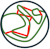

This notebook, derived from MMSEQ2, GREMLIN and ColabFold, performs a GREMLIN direct coupling analysis of coevolution on an input structure, and then plots this against the structure to see the level of coevolution agreement.

**Simply upload the .pdb file, select your cutoffs and away!**

Remember, coevolution whilst routed in genetic history is not an absolute sign that your proteins interact! However if this is shown in multiple instances, by alphafold and has agreement that indicates the interactions are more likely.

The output is in the form of a heatmap of coevolution, as well as a .pse file with connections between proteins output as red lines. Limit of 1000a.a combined gene lengths. Note: Selecting A100 GPU High RAM allows for up to 2500a.a combined gene lengths

In [ ]:
#@title Install Biopython
!pip install biopython

from collections import defaultdict
from Bio.PDB import PDBParser, MMCIFParser, PDBIO
from Bio.Data.IUPACData import protein_letters_3to1
from google.colab import files
import os

# ---------------------------
# Upload structure file
# ---------------------------
uploaded = files.upload()
filename = list(uploaded.keys())[0]
file_ext = os.path.splitext(filename)[1].lower()
print(f"Detected file type: {file_ext}")

# ---------------------------
# Parse structure (convert CIF → PDB if needed)
# ---------------------------
if file_ext == ".cif":
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("structure", filename)

    # Write out converted PDB
    io = PDBIO()
    io.set_structure(structure)
    pdb_filename = filename.replace(".cif", ".pdb")
    io.save(pdb_filename)
    print(f"Converted CIF to PDB: {pdb_filename}")

else:
    pdb_filename = filename

parser = PDBParser(QUIET=True)
structure = parser.get_structure("structure", pdb_filename)

# ---------------------------
# Extract 1-letter sequence for each REAL PDB chain
# Chain breaks are ignored
# ---------------------------
def get_chain_sequence(chain):
    seq = ""
    for res in chain.get_residues():

        # Skip hetero atoms (water, ligands, etc.)
        if res.id[0] != " ":
            continue

        # Convert 3-letter → 1-letter; unknown → X
        resname = res.resname.capitalize()  # e.g., "Ala", "Gly", etc.
        aa = protein_letters_3to1.get(resname, "X")
        seq += aa

    return seq


sequence_to_chains = defaultdict(list)
chain_sequences = {}

for model in structure:
    for chain in model:
        seq = get_chain_sequence(chain)
        if seq:  # Only include chains with residues
            chain_sequences[chain.id] = seq
            sequence_to_chains[seq].append(chain.id)

# ---------------------------
# Build job list and combined query sequence
# ---------------------------
jobs = []
for i, (seq, chains) in enumerate(sequence_to_chains.items(), 1):
    job_id = f"Job_{i}"
    jobs.append((job_id, seq, chains))

query_sequence = ":".join(seq for _, seq, _ in jobs)

# ---------------------------
# Output results
# ---------------------------
print("\n===== Extracted Chain Sequences (ignoring chain breaks) =====")
for chain_id, seq in chain_sequences.items():
    print(f"Chain {chain_id}: length {len(seq)}")
    print(seq)
    print()

print("\n===== Query Sequence =====")
print(query_sequence)

print("\n===== Job Info =====")
for job_id, seq, chains in jobs:
    print(f"{job_id}: {len(chains)} chain(s) "
          f"({', '.join(chains)}) - Length: {len(seq)}")


In [ ]:
#@title Upload a pre-computed coevolution matrix for the complex (e.g. PyCoM, CCMpred, plmc, GREMLIN)
#@markdown Run the structure upload cell above first. The matrix must cover the complex sequence printed there
#@markdown (the unique chains joined in that order, one row and column per residue), as produced by a paired alignment.
#@markdown
#@markdown **Accepted files**
#@markdown - an L × L matrix: `.npy`, `.npz`, `.csv`, `.tsv`, `.txt`, or a CCMpred `.mat` file
#@markdown - a pair list with three columns `i j score` (`.csv`, `.tsv`, `.txt`)
#@markdown - a plmc couplings file (`-c` output, six columns: `i A_i j A_j 0 score`)
#@markdown
#@markdown PyCoM matrices can be saved from Python with `numpy.save("matrix.npy", matrix)` and uploaded here.
#@markdown ---
jobname = "custom" #@param {type:"string"}
#@markdown Leave blank to use the chain sequences from the uploaded structure. Otherwise paste the sequence the matrix
#@markdown was calculated for, with ":" between proteins.
sequence = "" #@param {type:"string"}
if not sequence.strip():
    sequence = globals().get("query_sequence", "")
#@markdown Residue numbering in pair lists / plmc files.
PAIR_LIST_NUMBERING = "1-based" #@param ["1-based", "0-based"]
#@markdown Apply the average product correction (APC). Untick if your matrix is already APC-corrected
#@markdown (check the documentation of the source; CCMpred output is APC-corrected by default).
APPLY_APC = True #@param {type:"boolean"}
#@markdown Scores are converted to Z-scores exactly as in the GREMLIN version of the notebook, so the same thresholds apply.

import os, io, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import squareform

try:
    from google.colab import files
    _up = files.upload()
    matrix_file = next(iter(_up.keys()))
except Exception:
    matrix_file = globals().get("MATRIX_FILE", "")      # outside Colab: set MATRIX_FILE first
assert matrix_file and os.path.exists(matrix_file), "No matrix file uploaded."
print("Matrix file:", matrix_file)


def _read_table(path):
    txt = open(path).read()
    lines = [l for l in txt.splitlines() if l.strip() and not l.lstrip().startswith(("#", ">"))]
    sep = "," if lines[0].count(",") >= 1 else None
    rows = [re.split(r"\s+", l.strip()) if sep is None else [x.strip() for x in l.split(",")] for l in lines]
    # drop a header row of non-numbers
    def isnum(x):
        try:
            float(x); return True
        except ValueError:
            return False
    if not isnum(rows[0][0]):          # header line (first field is not a number)
        rows = rows[1:]
    return rows


def load_matrix(path):
    low = path.lower()
    if low.endswith(".npy"):
        return np.load(path, allow_pickle=False).astype(float), "L × L matrix (.npy)"
    if low.endswith(".npz"):
        z = np.load(path, allow_pickle=False)
        key = list(z.keys())[0]
        return z[key].astype(float), f"L × L matrix (.npz, array '{key}')"
    rows = _read_table(path)
    ncol = {len(r) for r in rows}
    n = len(rows)
    if len(ncol) == 1 and ncol.pop() == n:                       # square: dense matrix
        return np.array(rows, dtype=float), "L × L matrix (text)"
    width = len(rows[0])
    off = 1 if PAIR_LIST_NUMBERING == "1-based" else 0
    if width == 6:                                               # plmc couplings: i A_i j A_j 0 score
        I = [int(r[0]) - off for r in rows]; J = [int(r[2]) - off for r in rows]; S = [float(r[5]) for r in rows]
        kind = "plmc couplings file"
    elif width >= 3:                                             # pair list: i j score
        I = [int(float(r[0])) - off for r in rows]; J = [int(float(r[1])) - off for r in rows]; S = [float(r[2]) for r in rows]
        kind = "pair list (i j score)"
    else:
        raise ValueError("Could not recognise the file format.")
    L = max(max(I), max(J)) + 1
    M = np.zeros((L, L))
    M[I, J] = S; M[J, I] = S
    return M, kind


M, kind = load_matrix(matrix_file)
assert M.ndim == 2 and M.shape[0] == M.shape[1], f"Matrix must be square, got {M.shape}"
M = np.nan_to_num((M + M.T) / 2.0)          # symmetric
np.fill_diagonal(M, 0.0)
L = M.shape[0]
print(f"Read {kind}: L = {L}")

sequence = re.sub("[^A-Z:]", "", str(sequence).upper())
if sequence:
    seq_flat = sequence.replace(":", "")
    if len(seq_flat) != L:
        print(f"WARNING: the sequence has {len(seq_flat)} residues but the matrix has {L}; check they match.")
else:
    seq_flat = ""
query_sequence = sequence
seq = seq_flat
u_sequences = [s for s in sequence.split(":") if s] if sequence else []


def normalize(x):
    x = stats.boxcox(x - np.amin(x) + 1.0)[0]
    return (x - np.mean(x)) / np.std(x)

# same steps as the GREMLIN notebook: raw -> APC -> Box-Cox -> Z-score, on the upper triangle
raw_sq = M.copy()
if APPLY_APC:
    ap = raw_sq.sum(0, keepdims=True) * raw_sq.sum(1, keepdims=True) / raw_sq.sum()
    apc_sq = raw_sq - ap
else:
    apc_sq = raw_sq
np.fill_diagonal(apc_sq, 0.0)
i_idx, j_idx = np.triu_indices(L, k=1)
mtx = {"i": i_idx, "j": j_idx,
       "raw": raw_sq[i_idx, j_idx], "apc": apc_sq[i_idx, j_idx],
       "zscore": normalize(apc_sq[i_idx, j_idx]), "len": L}
# 1-based residue labels, as in the GREMLIN version (index i -> residue i+1 of the joined sequence)
if seq_flat and len(seq_flat) == L:
    mtx["i_aa"] = [f"{seq_flat[a]}_{a+1}" for a in mtx["i"]]
    mtx["j_aa"] = [f"{seq_flat[b]}_{b+1}" for b in mtx["j"]]
else:
    mtx["i_aa"] = [f"X_{a+1}" for a in mtx["i"]]
    mtx["j_aa"] = [f"X_{b+1}" for b in mtx["j"]]
seqs = [seq_flat]
pd_mtx = pd.DataFrame(mtx, columns=["i", "j", "raw", "apc", "zscore", "i_aa", "j_aa"])
coev_mtx = pd.DataFrame(mtx, columns=["i", "j", "zscore"])
depthratio = float("nan")      # not known for an imported matrix

def plot_mtx(mtx):
    m = np.full((mtx["len"], mtx["len"]), np.nan)
    m[mtx["i"], mtx["j"]] = mtx["zscore"]; m[mtx["j"], mtx["i"]] = mtx["zscore"]
    plt.figure(figsize=(8, 8))
    plt.title(f"Co-Evolution Matrix (imported, Z-score): {os.path.basename(matrix_file)}")
    plt.imshow(m, cmap="Blues", vmin=0.5, vmax=3)
    if ":" in query_sequence:
        for b in np.cumsum([len(x) for x in query_sequence.split(":")])[:-1]:
            plt.axvline(b - 0.5, color="red", lw=0.8); plt.axhline(b - 0.5, color="red", lw=0.8)
    plt.xlabel("Protein Amino acids"); plt.grid(False)
    plt.savefig(f"co-ev{jobname}.png"); plt.show()

plot_mtx(mtx)
print(f"{len(coev_mtx):,} residue pairs; Z-score range {coev_mtx.zscore.min():.2f} to {coev_mtx.zscore.max():.2f}. "
      "Continue with the cells below.")


In [ ]:
!python -m pip install --upgrade pip
!pip install tr-rosetta-pytorch
!apt-get install pymol

In [ ]:
!pip install biopython matplotlib numpy


In [ ]:
from Bio.PDB import PDBParser, PDBIO, Select

# Parse original structure
parser = PDBParser(QUIET=True)
structure = parser.get_structure("structure", pdb_filename)

# Renumber residues per chain
for model in structure:
    for chain in model:
        new_id = 1
        for residue in chain.get_residues():
            if residue.id[0] == ' ':  # Only standard residues (ignore hetero/water)
                residue.id = (' ', new_id, ' ')
                new_id += 1

# Save to new file
renumbered_filename = pdb_filename
io = PDBIO()
io.set_structure(structure)
io.save(renumbered_filename)
print(f"Saved renumbered PDB: {renumbered_filename}")

In [ ]:
import numpy as np
import pandas as pd

# Threshold for filtering coevolving residues
GREM_threshold = 2  # @param

# Load your matrix, assuming 'i', 'j', 'zscore' columns exist
new_df = pd_mtx[['i', 'j', 'zscore']].copy()

# Parse query sequence into individual job sequences
job_seqs = query_sequence.split(':')
job_boundaries = np.cumsum([0] + [len(seq) for seq in job_seqs])  # Get index boundaries per job

# Container for final results
results = []

# Loop over all unique inter-job pairs (i < j)
for i in range(len(job_seqs)):
    for j in range(i+1, len(job_seqs)):
        start_i, end_i = job_boundaries[i], job_boundaries[i+1]
        start_j, end_j = job_boundaries[j], job_boundaries[j+1]

        # Filter interactions between job_i and job_j
        df = new_df[
            (new_df['i'] >= start_i) & (new_df['i'] < end_i) &
            (new_df['j'] >= start_j) & (new_df['j'] < end_j) &
            ((new_df['j'] - new_df['i']) > 5) &
            (new_df['zscore'] > GREM_threshold)
        ].copy()

        if df.empty:
            continue

        # Adjust residue indices to be local to their respective jobs
        df['Aaa-B'] = df['i'] - start_i + 1  # 1-based indexing
        df['A-Baa'] = df['j'] - start_j + 1
        df['A-B-Score'] = df['zscore']

        # Select and reorder columns
        df = df[['Aaa-B', 'A-Baa', 'A-B-Score']]

        job_pair_label = f"{i+1}-{j+1}"
        df.columns = [f"{job_pair_label}-Aaa-B", f"{job_pair_label}-A-Baa", f"{job_pair_label}-A-B-Score"]

        # Store result
        results.append(df)

# Concatenate all inter-job interactions
if results:
    final_df = pd.concat(results, axis=1)
    final_df.to_csv('sorted_file.csv', sep=' ', index=False)
    print(final_df)
else:
    print("No inter-job interactions above threshold.")


In [ ]:
import pandas as pd
from google.colab import files
!curl -L -O "https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-$(uname)-$(uname -m).sh"
!bash Miniforge3-Linux-x86_64.sh -b -p /content/mambaforge -u

# Force PATH update in the shell
!export PATH=/content/mambaforge/bin:$PATH

In [ ]:
from Bio.PDB import PDBParser, PDBIO, Select

# Define selector that includes only standard amino acids
class OnlyAminoAcids(Select):
    def accept_residue(self, residue):
        return residue.id[0] == ' '  # Only accept standard residues (no HETATM)

# Parse the structure
parser = PDBParser(QUIET=True)
structure = parser.get_structure("structure", pdb_filename)

# Save only amino acids to new PDB
io = PDBIO()
io.set_structure(structure)
io.save(pdb_filename, OnlyAminoAcids())

print(f"Saved cleaned PDB without non-amino acids: {pdb_filename}")

In [ ]:
from collections import defaultdict
from Bio.Data.IUPACData import protein_letters_3to1

# ---------------------------
# Extract sequences per TRUE chain (ignoring chain breaks)
# ---------------------------
def get_chain_sequence(chain):
    seq = ""
    for res in chain.get_residues():
        if res.id[0] != " ":   # Skip ligands, waters
            continue
        aa = protein_letters_3to1.get(res.resname.capitalize(), "X")
        seq += aa
    return seq

sequence_to_chains = defaultdict(list)
chain_sequences = {}

for model in structure:
    for chain in model:
        seq = get_chain_sequence(chain)
        if seq:
            chain_sequences[chain.id] = seq
            sequence_to_chains[seq].append(chain.id)

# ---------------------------
# Build jobs based on unique sequences
# ---------------------------
jobs = []
for i, (seq, chains) in enumerate(sequence_to_chains.items(), start=1):
    job_id = f"Job_{i}"
    jobs.append((job_id, seq, chains))

# ---------------------------
# Build job_info (NEEDED for PyMOL code)
# ---------------------------
job_info = [
    {
        "job_id": job_id,
        "sequence_length": len(seq),
        "chains": chains
    }
    for job_id, seq, chains in jobs
]

print("Job Info Rebuilt:")
for j in job_info:
    print(j)

import pandas as pd
from google.colab import files
import random
import os
import sys

# ---------------------------
# PyMOL installation environment fixes
# ---------------------------
os.environ['PATH'] = f"/content/mambaforge/bin:{os.environ['PATH']}"
sys.path.append('/content/mambaforge/lib/python3.10/site-packages')

# Clear PYTHONPATH to prevent conflicts
if 'PYTHONPATH' in os.environ:
    del os.environ['PYTHONPATH']

!which mamba
!mamba --version
!mamba install -c conda-forge pymol-open-source -y
!mamba install -c conda-forge tqdm -y

# ---------------------------
# Parameters
# ---------------------------
GREM_threshold = 2.5     #@param Interaction score cutoff
Angstrom_cutoff = 20     #@param Distance measurement cutoff
jobname = os.path.splitext(pdb_filename)[0]  # Name from uploaded PDB

# ---------------------------
# Load GREMLIN output
# ---------------------------
df = pd.read_csv('sorted_file.csv', sep=' ')

# ---------------------------
# PyMOL script assembly
# ---------------------------
color_list = [
    "red", "blue", "green", "orange", "purple", "cyan", "yellow",
    "magenta", "lime", "salmon", "deepsalmon", "tv_blue", "marine",
    "hotpink", "wheat", "forest", "chocolate", "slate"
]

pym_script = []
pym_script.append(f"cmd.load('{pdb_filename}')")
pym_script.append('cmd.color("gray90")')
pym_script.append('cmd.cartoon("automatic")')
pym_script.append('cmd.set("dash_radius", 0.4)')
pym_script.append('cmd.bg_color("white")')

# ---------------------------
# Extract job pair prefixes
# ---------------------------
job_pairs = set()
for col in df.columns:
    if col.endswith('-A-B-Score'):
        pair = col.replace('-A-B-Score', '')
        job_pairs.add(pair)

job_pair_colors = {
    pair: color_list[i % len(color_list)]
    for i, pair in enumerate(sorted(job_pairs))
}

# ---------------------------
# Map job IDs → chain list from new job_info format
# ---------------------------
# job_info looks like: { "job_id": "Job_1", "sequence_length": XX, "chains": ["A","C"] }
job_id_to_chains = {
    entry["job_id"]: entry["chains"]
    for entry in job_info
}

# ---------------------------
# Generate PyMOL measurements
# ---------------------------
for pair in job_pairs:

    # GREMLIN columns
    A_col = f"{pair}-Aaa-B"
    B_col = f"{pair}-A-Baa"
    score_col = f"{pair}-A-B-Score"

    # Skip missing columns
    if not all(col in df.columns for col in [A_col, B_col, score_col]):
        continue

    # Filter hits
    subset = df[[A_col, B_col, score_col]].dropna()
    subset = subset[subset[score_col] > GREM_threshold]

    # Parse job IDs (example: "1-2" → Job_1 and Job_2)
    job1_idx, job2_idx = pair.split('-')
    job1_id = f"Job_{job1_idx}"
    job2_id = f"Job_{job2_idx}"

    chain_set_1 = job_id_to_chains.get(job1_id, [])
    chain_set_2 = job_id_to_chains.get(job2_id, [])

    color = job_pair_colors[pair]

    # Build distance commands
    for _, row in subset.iterrows():
        resA = int(row[A_col])
        resB = int(row[B_col])

        for c1 in chain_set_1:
            for c2 in chain_set_2:
                label = f"d{resA}-{resB}_{c1}{c2}_{pair}"

                pym_script.append(
                    f'cmd.distance("{label}", '
                    f'"resi {resA} and name CA and chain {c1}", '
                    f'"resi {resB} and name CA and chain {c2}", '
                    f'{Angstrom_cutoff})'
                )
                pym_script.append(
                    f'cmd.set("dash_color", "{color}", "{label}")'
                )

# ---------------------------
# Save PyMOL session file
# ---------------------------
pym_script.append(f'cmd.save("{jobname}.pse")')

# Write script to disk
with open("script.py", "w") as out:
    out.write("\n".join(pym_script))

# Run PyMOL headless
!pymol -cq script.py

# Download session
files.download(f"{jobname}.pse")


In [ ]:
#@title Top-L/5 precision: intermolecular (inter-chain) contacts only
import numpy as np
import pandas as pd
from Bio.PDB import PDBParser

pdb_path = pdb_filename
contact_dist = 15.0  #@param {type:"number"}
use_zscore_filter = True  #@param {type:"boolean"}
zscore_threshold = 2  #@param {type:"number"}

# --- CB (CA for glycine) coordinates for EVERY chain, concatenated in PDB chain order ---
parser = PDBParser(QUIET=True)
structure = parser.get_structure("s", pdb_path)

coords = []
chain_of_residue = []

for chain_idx, chain in enumerate(structure[0].get_chains()):
    for res in chain:
        if res.id[0] != ' ':
            continue
        atom_name = "CA" if res.get_resname() == "GLY" else "CB"
        if atom_name in res:
            coords.append(res[atom_name].coord)
        elif "CA" in res:
            coords.append(res["CA"].coord)
        else:
            coords.append([np.nan]*3)
        chain_of_residue.append(chain_idx)

coords = np.array(coords)
chain_of_residue = np.array(chain_of_residue)
L_struct = len(coords)
n_chains = chain_of_residue.max() + 1
print(f"Parsed {L_struct} residues across {n_chains} chain(s)")

diff = coords[:, None, :] - coords[None, :, :]
dist_mtx = np.sqrt(np.nansum(diff**2, axis=-1))
true_contacts = dist_mtx < contact_dist

# --- predicted pairs from mtx: inter-chain only, then optional z-score filter ---
i_arr, j_arr, score_arr = mtx["i"], mtx["j"], mtx["zscore"]

valid_idx = (i_arr < L_struct) & (j_arr < L_struct)
i_arr, j_arr, score_arr = i_arr[valid_idx], j_arr[valid_idx], score_arr[valid_idx]

interchain_mask = chain_of_residue[i_arr] != chain_of_residue[j_arr]
i_ic, j_ic, score_ic = i_arr[interchain_mask], j_arr[interchain_mask], score_arr[interchain_mask]
n_interchain_total = len(i_ic)

if use_zscore_filter:
    z_mask = score_ic > zscore_threshold
    i_ic, j_ic, score_ic = i_ic[z_mask], j_ic[z_mask], score_ic[z_mask]

n_candidates = len(i_ic)

chain_lengths = [np.sum(chain_of_residue == c) for c in range(n_chains)]
L_interface = min(chain_lengths)
requested_top_n = max(1, L_interface // 5)
top_n = min(requested_top_n, n_candidates)

print(f"Chain lengths: {chain_lengths}  ->  L (shorter chain) = {L_interface}, requested top-L/5 = {requested_top_n}")
print(f"Z-score filter: {'ON, zscore > ' + str(zscore_threshold) if use_zscore_filter else 'OFF (all inter-chain pairs eligible)'}")
print(f"Inter-chain candidate pairs: {n_interchain_total} total" + (f", {n_candidates} after z-filter" if use_zscore_filter else ""))

if top_n == 0:
    print("No candidate pairs available - precision undefined.")
    precision = float("nan")
else:
    if top_n < requested_top_n:
        print(f"NOTE: only {n_candidates} candidate pair(s) available, below requested top-{requested_top_n} - using all {top_n}.")
    order = np.argsort(score_ic)[::-1][:top_n]
    top_i, top_j = i_ic[order], j_ic[order]
    hits = true_contacts[top_i, top_j]
    precision = hits.sum() / top_n
    print(f"Intermolecular Top-L/5 precision: {precision:.3f}  ({hits.sum()}/{top_n} true contacts, CB-CB < {contact_dist} A)")

In [ ]:
#@title Top-L/5 precision vs z-score threshold (sweep + plot)
z_min = 0.0    #@param {type:"number"}
z_max = 4.0    #@param {type:"number"}
z_step = 0.25  #@param {type:"number"}

# rebuilds the unfiltered inter-chain candidate pool fresh - independent of whatever
# use_zscore_filter was set to in the single-threshold cell above
i_arr, j_arr, score_arr = mtx["i"], mtx["j"], mtx["zscore"]
valid_idx = (i_arr < L_struct) & (j_arr < L_struct)
i_arr, j_arr, score_arr = i_arr[valid_idx], j_arr[valid_idx], score_arr[valid_idx]
interchain_mask = chain_of_residue[i_arr] != chain_of_residue[j_arr]
i_ic_all, j_ic_all, score_ic_all = i_arr[interchain_mask], j_arr[interchain_mask], score_arr[interchain_mask]

def precision_at_threshold(z_thresh):
    mask = score_ic_all > z_thresh
    i_f, j_f, score_f = i_ic_all[mask], j_ic_all[mask], score_ic_all[mask]
    n_candidates = len(i_f)
    top_n = min(requested_top_n, n_candidates)
    if top_n == 0:
        return n_candidates, top_n, np.nan
    order = np.argsort(score_f)[::-1][:top_n]
    hits = true_contacts[i_f[order], j_f[order]].sum()
    return n_candidates, top_n, hits / top_n

thresholds = np.arange(z_min, z_max + z_step / 2, z_step)
sweep_rows = []
for z in thresholds:
    n_candidates, top_n, precision = precision_at_threshold(z)
    sweep_rows.append({"zscore_threshold": z, "n_candidates": n_candidates, "top_n_used": top_n, "precision": precision})

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

ax1.plot(sweep_df["zscore_threshold"], sweep_df["precision"], marker="o")
ax1.set_ylabel("Top-L/5 precision")
ax1.set_ylim(0, 1)
ax1.set_title("Intermolecular Top-L/5 precision vs z-score threshold")
ax1.grid(True, alpha=0.3)

ax2.plot(sweep_df["zscore_threshold"], sweep_df["n_candidates"], marker="o", color="gray")
ax2.set_xlabel("z-score threshold (pairs kept if zscore > threshold)")
ax2.set_ylabel("candidate pairs\nabove threshold")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{jobname}_precision_vs_zscore.png")
plt.show()